In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord

In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


## Define a useful cleaning function

In [4]:
# Let's start by making color-redshift plot for redmagic
def remove_outliers(data, bands):
    # All bands are good <3
    catlen = len(data)
    wg = np.full(catlen, True)

    # Pick out only the good entries!
    for band in bands:
        band_mag = np.ma.getdata(data[band])
        band_bool = (band_mag > -9999) & (band_mag != np.nan) & (band_mag < 28)
        wg *= band_bool

    # percent of galaxies that failed
    pfail = 100-(np.count_nonzero(wg) / catlen * 100)

    # How many failed?
    print(f'RedshiftCalc: {np.count_nonzero(wg)}/{catlen} galaxies',
          f'({100-pfail:.1f}%) have good photometry')
    print(f'RedshiftCalc: removing {pfail:.1f}% of galaxies from data')
    print('')

    return wg

In [5]:
catalog_path = '/Users/j.mccleary/Research/dusty_halos/catalogs/prep_cat_output'
hiz = Table.read(os.path.join(catalog_path, 'redmagic_hiz_y3_GOLD_JOINED_catalog.fits'))
hidens = Table.read(os.path.join(catalog_path,'redmagic_hidens_y3_GOLD_JOINED_catalog.fits'))


In [6]:
bands = ['mof_cm_mag_corrected_g', 'mof_cm_mag_corrected_r',
        'mof_cm_mag_corrected_i', 'mof_cm_mag_corrected_z']


wg_hiz = remove_outliers(hiz, bands)
hiz = hiz[wg_hiz]
wg_hidens = remove_outliers(hidens, bands)
hidens = hidens[wg_hidens]

RedshiftCalc: 814104/816199 galaxies (99.7%) have good photometry
RedshiftCalc: removing 0.3% of galaxies from data

RedshiftCalc: 1768455/1772050 galaxies (99.8%) have good photometry
RedshiftCalc: removing 0.2% of galaxies from data



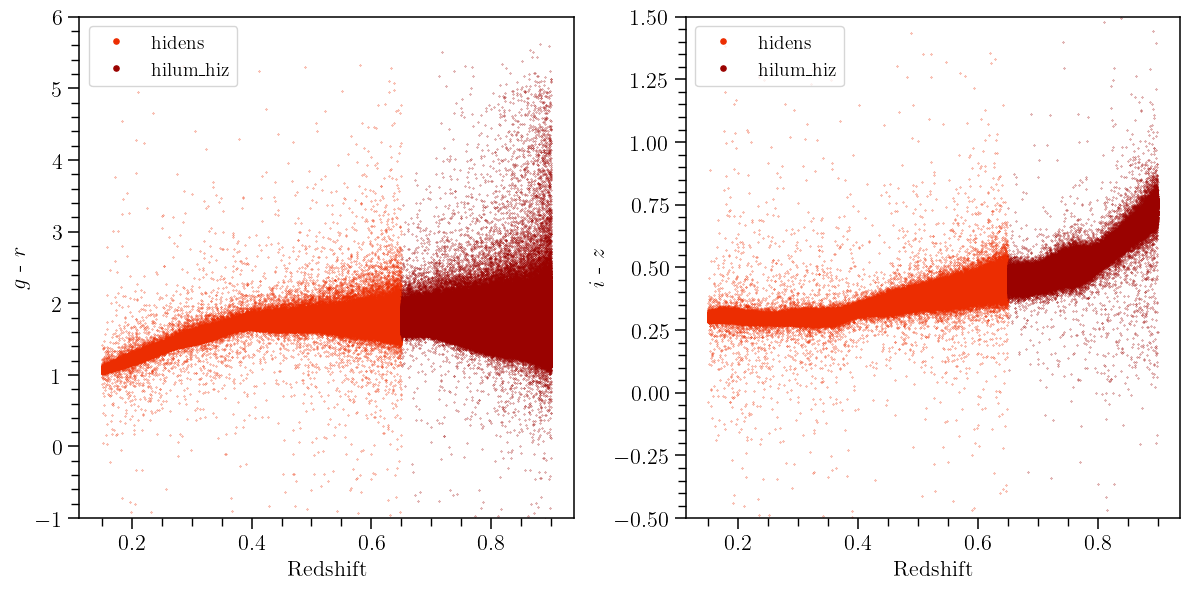

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12,6), tight_layout=True)
axs[0].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_g'] - hidens['mof_cm_mag_corrected_r']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[0].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_g'] - hiz['mof_cm_mag_corrected_r']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[0].set_ylim(-1,6)
axs[0].legend(markerscale=15, loc='upper left')
axs[0].set_xlabel('Redshift')
axs[0].set_ylabel(r'$g$ - $r$')

axs[1].plot(hidens['zredmagic'], 
            (hidens['mof_cm_mag_corrected_i'] - hidens['mof_cm_mag_corrected_z']), 
            '.', markersize=0.5, color='xkcd:tomato red', label='hidens')
axs[1].plot(hiz['zredmagic'], 
            (hiz['mof_cm_mag_corrected_i'] - hiz['mof_cm_mag_corrected_z']), 
             '.', markersize=0.5, color='xkcd:deep red', label='hilum_hiz')
axs[1].set_ylim(-0.5,1.5)
axs[1].legend(markerscale=15, loc='upper left')
axs[1].set_xlabel('Redshift')
axs[1].set_ylabel(r'$i$ - $z$')

fig.savefig('color_redshift_redmagic.pdf')
fig.savefig('color_redshift_redmagic.png')

## OK, let's try Av histogram

In [4]:
catdir = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/'
#hiz_tcatname = 'redmagic_hiz/dust_correlation_ccm89_treecorrcat.fits'
#hiz_tcatname2 = 'redmagic_hiz/dust_correlation_ccm89_4zbins_treecorrcat.fits'
hiz_tcatname = 'redmagic_hiz/dust_correlation_calzetti00_treecorrcat.fits'
hiz_tcatname2 = 'redmagic_hiz/dust_correlation_calzetti00_4zbins_treecorrcat.fits'

hiz_tcat = Table.read(os.path.join(catdir, hiz_tcatname))
hiz_tcat2 = Table.read(os.path.join(catdir, hiz_tcatname2))

hidens_tcatname = 'redmagic_hidens/dust_correlation_calzetti00_treecorrcat.fits'
hidens_tcatname2 = 'redmagic_hidens/dust_correlation_calzetti00_8zbins_treecorrcat.fits'

hidens_tcat = Table.read(os.path.join(catdir, hidens_tcatname))
hidens_tcat2 = Table.read(os.path.join(catdir, hidens_tcatname2))


In [9]:
hiz_tcat.info()

<Table length=814104>
name  dtype 
---- -------
  ra float64
 dec float64
   w float64
   k float64


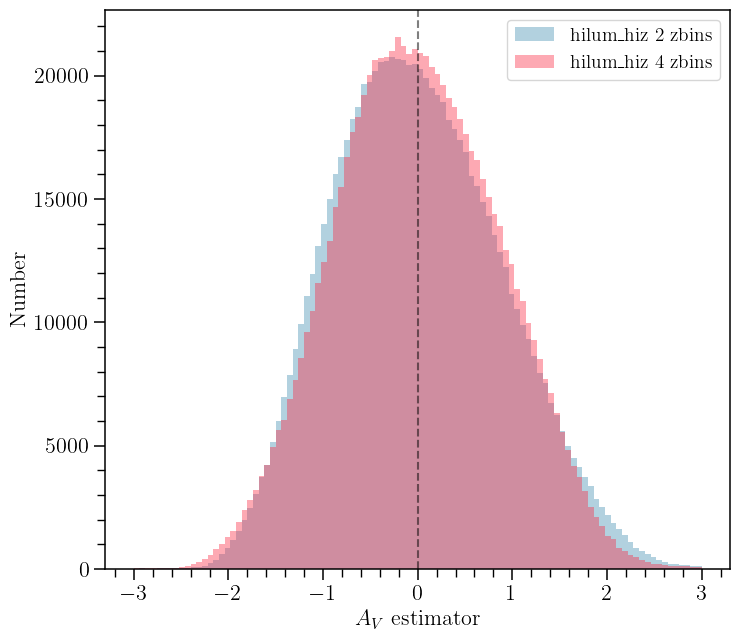

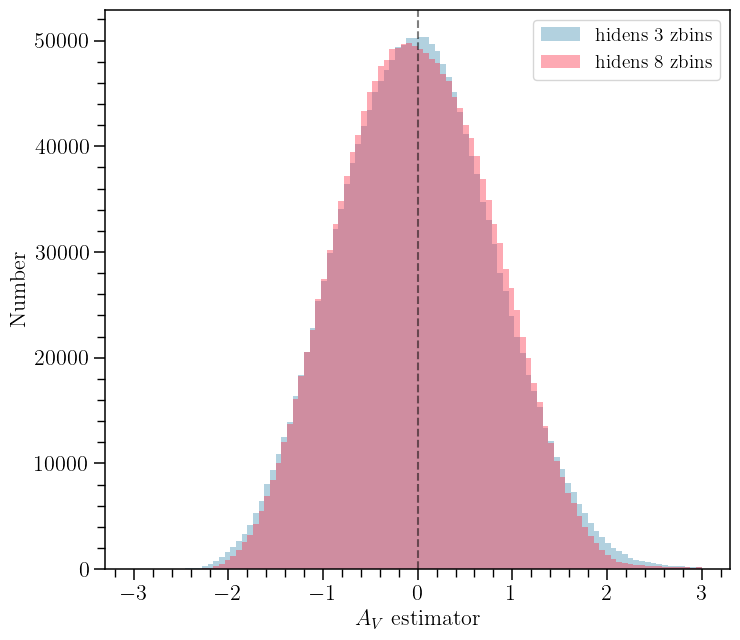

In [10]:
plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hiz_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hilum_hiz 2 zbins', alpha=0.3, color='xkcd:peacock blue')
plt.hist(hiz_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hilum_hiz 4 zbins', color='xkcd:strawberry', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.savefig('hilum_hiz_Av_hist_Calzetti00.pdf')
plt.savefig('hilum_hiz_Av_hist_Calzetti00.png')

###
### Now repeat for hidens
###

plt.figure(figsize=(7.5,6.5), tight_layout=True)
plt.hist(hidens_tcat['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hidens 3 zbins', alpha=0.3, color='xkcd:peacock blue')
plt.hist(hidens_tcat2['k'], bins=100, range=[-3, 3], histtype='bar', 
        label='hidens 8 zbins', color='xkcd:strawberry', alpha=0.4)

plt.axvline(0, ls='--', color='k', alpha=0.5)
plt.xlabel(r'$A_V$ estimator')
plt.ylabel('Number')
plt.legend()
plt.savefig('hidens_Av_hist.pdf')
plt.savefig('hidens_Av_hist.png')


In [11]:
hz_wg = np.abs(hiz_tcat['k'])<3
hz_wg2 = np.abs(hiz_tcat2['k'])<3

hiz_stats = stats.describe(hiz_tcat[hz_wg]['k'])
hiz_stats2 = stats.describe(hiz_tcat2[hz_wg2]['k'])

print('# ---------------------------')
print('# hilum_hiz 2 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats}')
print(f"median: {np.median(hiz_tcat[hz_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hilum_hiz 4 z bins statistics')
print('# ---------------------------')
print(f'{hiz_stats2}')
print(f"median: {np.median(hiz_tcat2[hz_wg]['k'])}")


### For hidens, now
hd_wg = np.abs(hidens_tcat['k'])<3
hd_wg2 = np.abs(hidens_tcat2['k'])<3

hidens_stats = stats.describe(hidens_tcat[hd_wg]['k'])
hidens_stats2 = stats.describe(hidens_tcat2[hd_wg2]['k'])

print('')
print('# ---------------------------')
print('# hidens 3 z bins statistics')
print('# ---------------------------')
print(hidens_stats)
print(f"median: {np.median(hidens_tcat[hd_wg]['k'])}")

print('')
print('# ---------------------------')
print('# hidens 8 z bins statistics')
print('# ---------------------------')
print(hidens_stats2)
print(f"median: {np.median(hidens_tcat2[hd_wg2]['k'])}")


# ---------------------------
# hilum_hiz 2 z bins statistics
# ---------------------------
DescribeResult(nobs=811705, minmax=(-2.997940091620914, 2.999877279163087), mean=0.002193184405222048, variance=0.7841153463571232, skewness=0.23831177519843263, kurtosis=-0.3307872439857089)
median: -0.04687681472028129

# ---------------------------
# hilum_hiz 4 z bins statistics
# ---------------------------
DescribeResult(nobs=811946, minmax=(-2.9983278926857633, 2.999119797576729), mean=0.0057954879965418996, variance=0.7448053157059811, skewness=0.07638214034641384, kurtosis=-0.3286542512853221)
median: -0.0180381862408943

# ---------------------------
# hidens 3 z bins statistics
# ---------------------------
DescribeResult(nobs=1763885, minmax=(-2.9991903369023216, 2.9998210945258226), mean=-0.003691351111635047, variance=0.6540791209575935, skewness=0.14166848294953024, kurtosis=-0.18891734912520386)
median: -0.018099069584088523

# ---------------------------
# hidens 8 z bins statis

In [ ]:
hidens_stats2.skewness

## Comparing redshift bins and dust models

In [61]:
###
### First, define some parameters
###

# Set z_theory and z_foreground levels
z_theory = 0.36 # Menard
z_fg = 0.088 # Filtered WISExSCOS

theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

scl = fg_gal_kpc.value
#theory_scl = 304*cosmo.h -- yields their answer
theory_scl = theory_kpc.value
xlabel_unit = 'kpc'
theory_r = np.logspace(-2,5,10)
av = 2.5e-3 * (theory_r/theory_scl)**(-0.86)


In [76]:
###
### Do pre-processing
###

### Hi-dens
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hidens/'
hidens_dk = Table.read(output_path+'dust_correlation_calzetti00_signal.fits')
hidens_fr = Table.read(output_path+'dust_correlation_calzetti00_fg_randoms.fits')
hidens_dr = Table.read(output_path+'dust_correlation_calzetti00_bg_randoms.fits')
hidens_rr = Table.read(output_path+'dust_correlation_calzetti00_fgxbg_randoms.fits')

hidens2_dk = Table.read(output_path+'dust_correlation_calzetti00_8zbins_signal.fits')
hidens2_fr = Table.read(output_path+'dust_correlation_calzetti00_8zbins_fg_randoms.fits')
hidens2_dr = Table.read(output_path+'dust_correlation_calzetti00_8zbins_bg_randoms.fits')
hidens2_rr = Table.read(output_path+'dust_correlation_calzetti00_8zbins_fgxbg_randoms.fits')

### Hi-z 
output_path2 = '/Users/j.mccleary/Research/dusty_halos/dusthalos/output/redmagic_hiz/'
hiz_dk = Table.read(output_path2+'dust_correlation_calzetti00_signal.fits')
hiz_fr = Table.read(output_path2+'dust_correlation_calzetti00_fg_randoms.fits')
hiz_dr = Table.read(output_path2+'dust_correlation_calzetti00_bg_randoms.fits')
hiz_rr = Table.read(output_path2+'dust_correlation_calzetti00_fgxbg_randoms.fits')

hiz2_dk = Table.read(output_path2+'dust_correlation_calzetti00_4zbins_signal.fits')
hiz2_fr = Table.read(output_path2+'dust_correlation_calzetti00_4zbins_fg_randoms.fits')
hiz2_dr = Table.read(output_path2+'dust_correlation_calzetti00_4zbins_bg_randoms.fits')
hiz2_rr = Table.read(output_path2+'dust_correlation_calzetti00_4zbins_fgxbg_randoms.fits')

### Now define signal 
dust_hidens = hidens_dk['kappa'] - hidens_fr['kappa'] - hidens_dr['kappa'] + hidens_rr['kappa']
dust_hidens2 = hidens2_dk['kappa'] - hidens2_fr['kappa'] - hidens2_dr['kappa'] + hidens2_rr['kappa']

dust_hiz = hiz_dk['kappa'] - hiz_fr['kappa'] - hiz_dr['kappa'] + hiz_rr['kappa']
dust_hiz2 = hiz2_dk['kappa'] - hiz_fr['kappa'] - hiz2_dr['kappa'] + hiz2_rr['kappa']

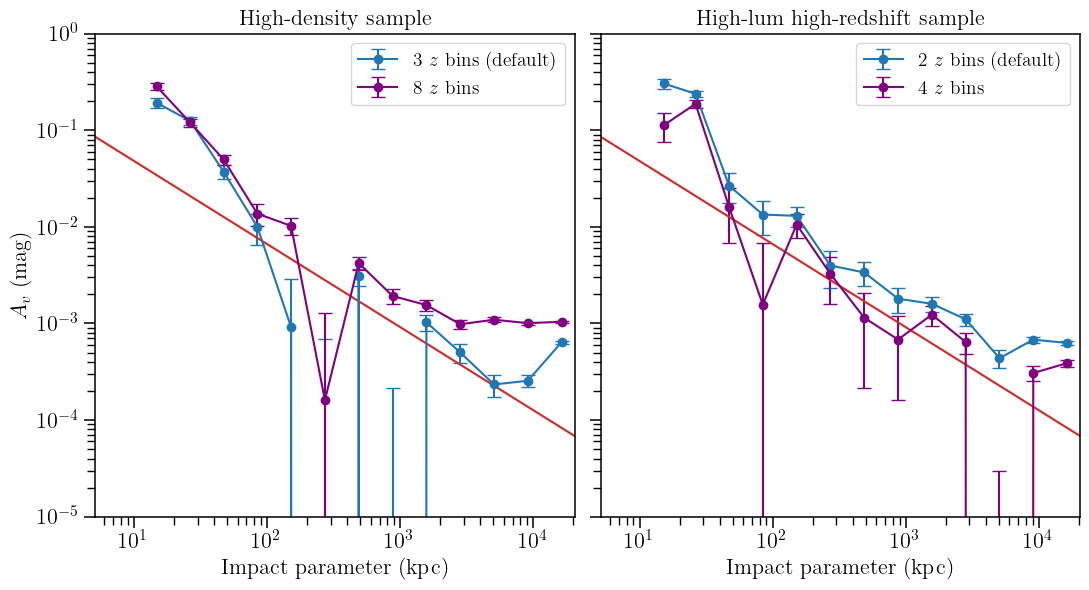

In [67]:
fig, ax = plt.subplots(1, 2, figsize=(11,6), tight_layout=True, sharey=True)

## First do hi-dens
ax[0].errorbar(hidens_dk['meanr']*scl, dust_hidens, yerr=hidens_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='3 $z$ bins (default)')
ax[0].errorbar(hidens2_dk['meanr']*scl, dust_hidens2, 
            yerr=hidens2_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='8 $z$ bins')
ax[0].plot(theory_r, av, color='tab:red')

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_xlim(0.05*scl, 200*scl)
ax[0].set_ylim(1E-5, 1)
ax[0].set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax[0].set_ylabel(r'$A_v$ (mag)', fontsize=16)
ax[0].legend()
ax[0].set_title('High-density sample')


## Now do high-z part
ax[1].errorbar(hiz_dk['meanr']*scl, dust_hiz, yerr=hiz_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='2 $z$ bins (default)')
ax[1].errorbar(hiz2_dk['meanr']*scl, dust_hiz2, 
            yerr=hiz2_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='4 $z$ bins')
ax[1].plot(theory_r, av, color='tab:red')

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim(0.05*scl, 200*scl)
ax[1].set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax[1].set_title('High-lum high-redshift sample')
ax[1].legend()

fig.savefig('figures/num_redshift_bins_comparision.pdf')
fig.savefig('figures/num_redshift_bins_comparision.png')


In [77]:
###
### OK, now repeat with different dust models
### 


hiz3_dk = Table.read(output_path2+'dust_correlation_ccm89_4zbins_signal.fits')
hiz3_fr = Table.read(output_path2+'dust_correlation_ccm89_4zbins_fg_randoms.fits')
hiz3_dr = Table.read(output_path2+'dust_correlation_ccm89_4zbins_bg_randoms.fits')
hiz3_rr = Table.read(output_path2+'dust_correlation_ccm89_4zbins_fgxbg_randoms.fits')

fm07_dk = Table.read(output_path2+'dust_correlation_fm07_4zbins_signal.fits')
fm07_fr = Table.read(output_path2+'dust_correlation_fm07_4zbins_fg_randoms.fits')
fm07_dr = Table.read(output_path2+'dust_correlation_fm07_4zbins_bg_randoms.fits')
fm07_rr = Table.read(output_path2+'dust_correlation_fm07_4zbins_fgxbg_randoms.fits')

### Now define signal 
### NOTE: It's the foreground x random correlation that is effing up my universe. 
### Don't know why. Maybe 
dust_hiz3 = hiz3_dk['kappa'] - hiz3_fr['kappa'] - hiz3_dr['kappa'] + hiz3_rr['kappa']
dust_fm07 = fm07_dk['kappa'] - fm07_fr['kappa'] - fm07_dr['kappa'] + fm07_rr['kappa']


Text(0.5, 1.0, 'High-redshift sample')

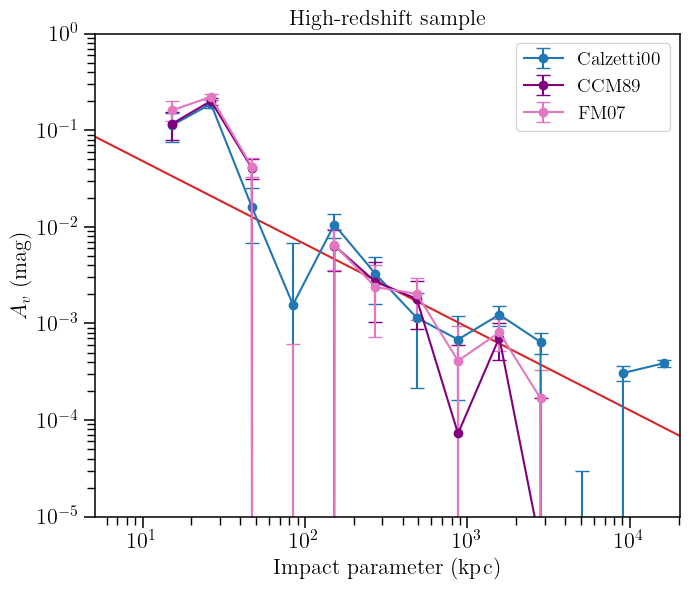

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(7,6), tight_layout=True, sharey=True)

## First do hi-dens
ax.errorbar(hiz2_dk['meanr']*scl, dust_hiz2, yerr=hiz2_dk['sigma'],
            fmt='-o',capsize=5, color='tab:blue',
            label='Calzetti00')
ax.errorbar(hiz3_dk['meanr']*scl, dust_hiz3, 
            yerr=hiz3_dk['sigma'], fmt='-o',capsize=5,
            color='purple', label='CCM89')
ax.errorbar(fm07_dk['meanr']*scl, dust_fm07, 
            yerr=fm07_dk['sigma'], fmt='-o',capsize=5,
            color='tab:pink', label='FM07')
ax.plot(theory_r, av, color='tab:red')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05*scl, 200*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(f'Impact parameter ({xlabel_unit})', fontsize=16)
ax.set_ylabel(r'$A_v$ (mag)', fontsize=16)
ax.legend()
ax.set_title('High-redshift sample')

#fig.savefig("figures/Calzetti_vs_CCM89_vs_FM07.png")
